# Beaver Simulation - Rumney Marsh, Boston (Monte Carlo)

This notebook runs a multi-agent beaver simulation on DEM (Digital Elevation Model) data from Rumney Marsh, Boston.

## Quick Start

1. Run Cell 1 to set up the project import path.
2. Review and adjust Cell 2 (`beavers_running_config`).
3. Run Cell 3 to run the Monte Carlo loop (one simulation per seed, results under `<save_path>/montecarlo/seed_<n>`).

## Configuration Reference (Cell 2)

### Top-Level
- **backend_type**: Agent-environment backend (`'beavers_visualizer'`).

### environment
- **name**: Environment backend name (`'beavers_environment'`).
- **elevation_file_path**: Path to elevation raster (`.npy`).
- **latitude_file_path**: Path to latitude grid (`.npy`).
- **longitude_file_path**: Path to longitude grid (`.npy`).
- **vegetation_quality_range**: `[min, max]` bounds for vegetation values.
- **grass_growth_interval**: Elevation interval where grass can grow.
- **grass_growth_rate**: Baseline vegetation growth rate.
- **grass_growth_sigma**: Stochastic variability of growth.
- **mean_reversion_strength**: Pull toward seasonal baseline.
- **visits_reset**: Decay factor applied to visit counts each step.
- **flow_info**: Water dynamics settings.
  - **river_growth_velocity**: River deepening rate over time.
  - **river_growth_interval**: Elevation interval where river growth applies.
  - **streams_depth**: Water depth threshold parameter.
  - **direction**: Flow direction vector `[x, y]`.
  - **strength**: Flow strength affecting movement.
- **print**: Enable/disable environment debug logs.

### robot
- **home_base_position**: Beaver lodge coordinate(s) `[[x, y]]`.
- **maximum_load**: Max carried load before return behavior.
- **harvest_interval**: Vegetation range where harvesting is allowed.
- **epsilon_greedy**: Exploration probability for epsilon-greedy policy.
- **exploration_eta**: Exploration randomness scale.
- **decay_values**: Adaptive decay values `[eta, harvest_interval, max_load]`.
- **role**: Agent role (`'explorer'` or `'builder'`).
- **controller**: Motion controller settings.
  - **name**: Controller type (`'P_repulsive'`).
  - **Kp, Kd, Ki**: PID gains.
  - **neighbourhood_size**: Local neighborhood size for repulsion.
  - **max**: Maximum movement speed.
  - **accuracy**: Position tolerance.
  - **dimension**: State-space dimension (2D).
  - **map_repulsive**: Repulsive potential source map.
  - **beta_repulsive**: Repulsion intensity.
- **dynamics**: Motion model parameters.
  - **name**: Dynamics model (`'integrator'`).
  - **mass**: Agent mass.
  - **friction**: Friction coefficient.
- **vegetation_removal**: Vegetation removed per harvest action.
- **visit_increase**: Visit-count increment per action.
- **exploration_map**: Exploration target map (`'vegetation_quality'` or `'vegetation_visits'`).
- **print**: Enable/disable robot debug logs.

### simulation
- **seed**: Random seed for reproducibility.
- **timedelta**: Simulation time step (hours).
- **schedule_policy**: Agent scheduling policy (`'sequential'`).
- **gui**: Enable simulation visualizer.
- **number_of_agents**: Number of beaver agents.
- **number_of_steps**: Total simulation steps.
- **downsampling**: Snapshot interval in steps.
- **save_path**: Output folder for snapshots/results.
- **print**: Enable simulation progress logs.

## Notes
- In Python dictionaries, duplicate keys keep the last assignment. In this config, the second `save_path` value is the one used at runtime.
- No additional parameters are documented here beyond what is currently set in Cell 2.

## Step 1 - Workspace Setup

Prepare imports and ensure the project root is on Python path.

In [7]:
# Setup: Add parent directory to Python path to import beaversim modules# Apply Gaussian blur to all images (increase/decrease sigma for stronger/weaker smoothing)
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
for parent in [cwd, *cwd.parents]:
    if (parent / 'beaversim').is_dir():
        project_root = parent
        break
else:
    raise RuntimeError("Could not locate project root containing 'beaversim'.")

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Project root: {project_root}")
print(f"Python path updated to include: {project_root}")

Project root: /home/fedeoli/Documents/Projects/TheLandscapeProject/BeaverSim
Python path updated to include: /home/fedeoli/Documents/Projects/TheLandscapeProject/BeaverSim


## Step 2 - Simulation Configuration

Define beavers_running_config with environment, robot, and simulation parameters.

In [8]:
from beaversim.scenarios.standard_beavers_scenario import standard_beavers_scenario

# ============================================================================
# BEAVER SIMULATION CONFIGURATION - RUMNEY MARSH, BOSTON
# ============================================================================

beavers_running_config = {
    # Agent-Environment coupling backend
    'backend_type': 'beavers_visualizer',
    
    # ========================================================================
    # ENVIRONMENT CONFIGURATION
    # ========================================================================
    'environment': {
        'name': 'beavers_environment',
        
        # --- Data Files (RGB outputs from utils/dem_conversion_interactive.ipynb) ---
        'elevation_file_path': '../../output/RumneyMarsh_Boston/DEM/elevation.npy',
        'latitude_file_path': '../../output/RumneyMarsh_Boston/DEM/latitude.npy',
        'longitude_file_path': '../../output/RumneyMarsh_Boston/DEM/longitude.npy',
        'metadata_file_path': '../../output/RumneyMarsh_Boston/DEM/processing_metadata.json',
        
        # --- Vegetation Dynamics ---
        'vegetation_quality_range': [0, 10],
        'grass_growth_interval': [0, 8],
        'grass_growth_rate': 0*5e-4,
        'grass_growth_sigma': 0.5,
        'mean_reversion_strength' : 0.0005,
        
        # --- Visitation Dynamics ---
        'visits_reset': 1.00,
        
        # --- Water/River Dynamics ---
        'flow_info': {
            'river_growth_velocity': 1e-4,
            'river_growth_interval': [-3, 0],
            'streams_depth': 10,
            'direction': [0, 0],
            'strength': 0.0,
        },
        
        'print': False,                           # Debug printing
    },
    
    # ========================================================================
    # BEAVER (ROBOT) CONFIGURATION
    # ========================================================================
    'robot': {   
        
        # --- Initial Position ---        
        'home_base_position': [[550, 410]],
        
        # -- Agent Cognitive and Behavioral Parameters 
        'maximum_load': [100, 100],
        'harvest_interval': [[2, 7], [2, 7]],
        'epsilon_greedy': [0.8, 1.0],
        'exploration_map': ['vegetation_visits', 'vegetation_visits'],
        'vegetation_removal': [1.0, 1.0],
        'role': ['explorer', 'builder'],
        
        # -- Dynamic Control and Model Parameters 
        'controller': {
            'name': 'P_repulsive',
            'Kp': 0.5,
            'Kd': 2.0,
            'Ki': 1e-5,
            'neighbourhood_size': 2,
            'accuracy': 5e-1,
            'map_repulsive': 'vegetation_quality',
            'beta_repulsive': 0.9,
        },
        # --- Physics Model ---
        'dynamics': {
            'name': 'integrator',
            'mass': 5,
            'friction': 1,
        },
        
        # -- Environmental and Stigmergic Coupling Parameters 
        'visit_increase': 1.0,    
        'decay_values': [0.050, 0.050],
        
        # Miscellaneous                        
        'print': False,
    },
    
    # ========================================================================
    # SIMULATION CONFIGURATION
    # ========================================================================
    'simulation': {
        'seed': 5,
        'timedelta': 1.0,
        'schedule_policy': 'sequential',
        'gui': True,
        'number_of_agents': 10,
        'number_of_steps': 365 * 0.5,
        'downsampling': 30,
        'save_path': '../../output/simulations/rumney_marsh_springer/10agents_6months_vegetation_visits',
        'print': True,
    },
}

## Step 3 - Monte Carlo Multi-Seed Simulation

Run multiple simulations with different random seeds and organize outputs by seed.


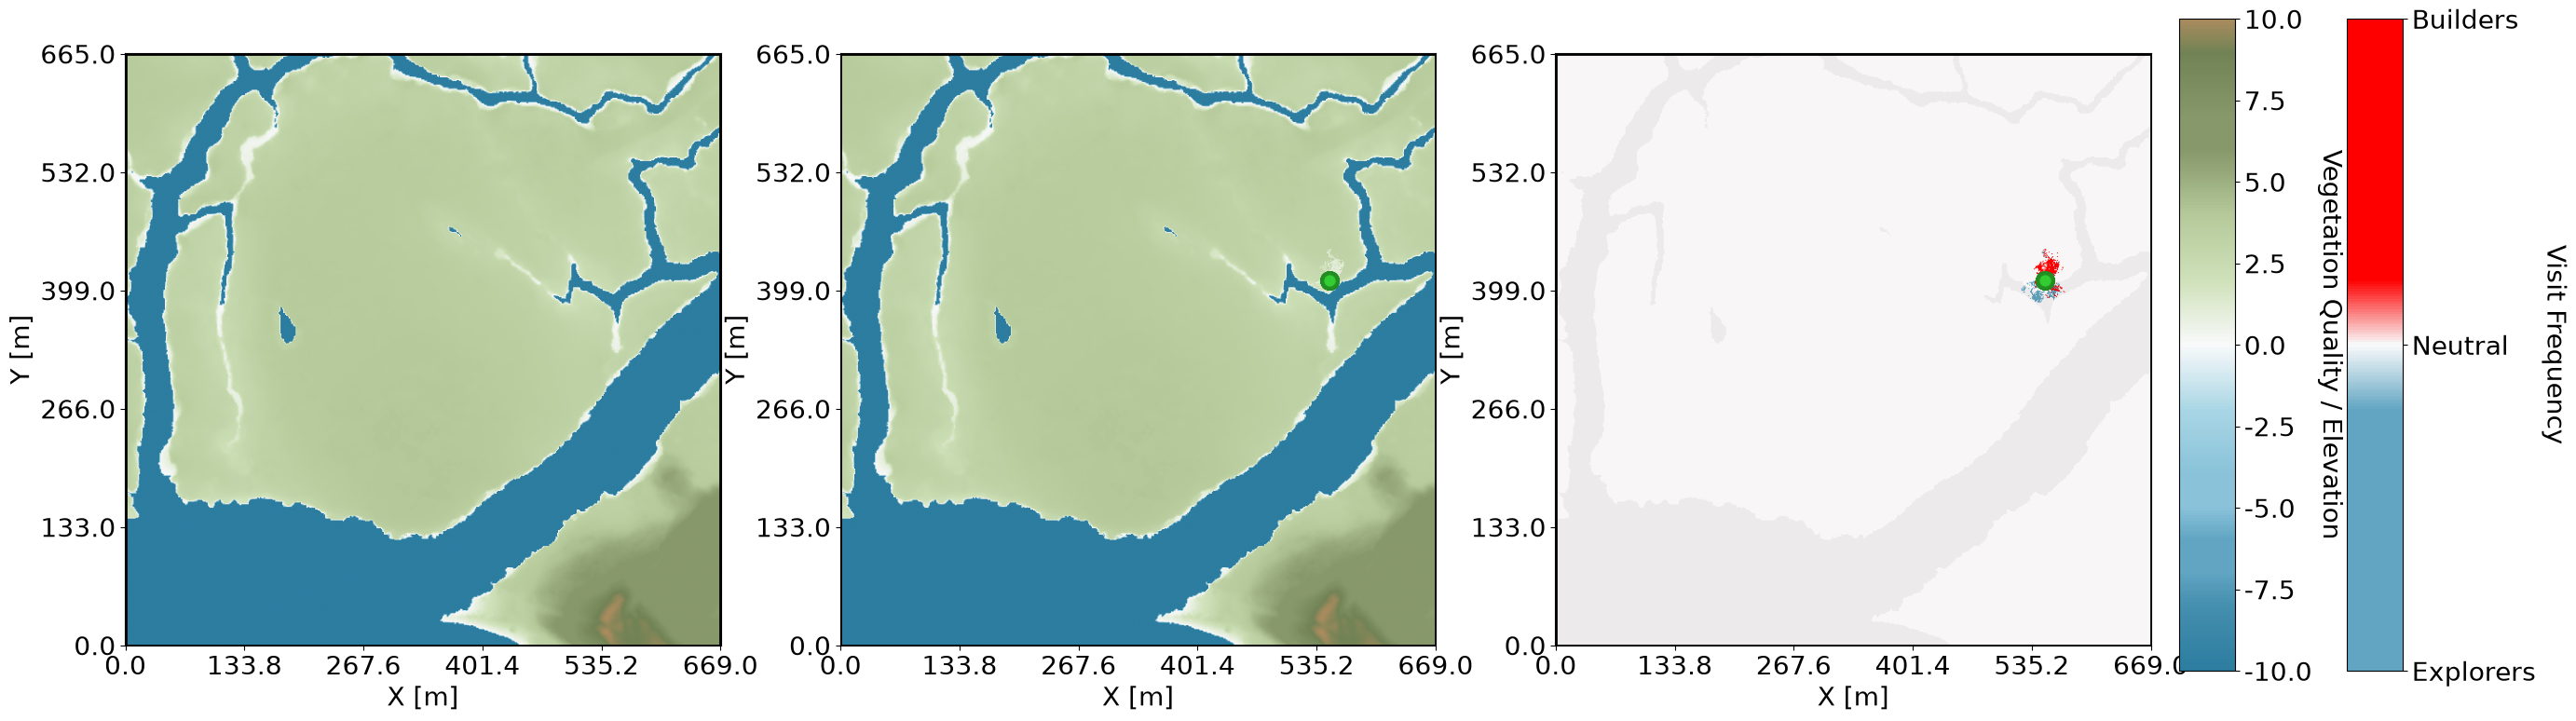

Environment map saved to: /home/fedeoli/Documents/Projects/TheLandscapeProject/BeaverSim/output/simulations/rumney_marsh_springer/temp
Original map shape (environment format): (669, 665)
Saved map shape: (665, 669)
Original value range: [-10.000, 10.000]
Saved value range: [-1.000, 1.000]
[-10.000, 10.000] -> [-1.0, 1.0]
Backend state saved to: /home/fedeoli/Documents/Projects/TheLandscapeProject/BeaverSim/output/simulations/rumney_marsh_springer/temp/final_backend.pkl.gz
✓ Output moved to: /home/fedeoli/Documents/Projects/TheLandscapeProject/BeaverSim/output/simulations/rumney_marsh_springer/10agents_6months_vegetation_visits/montecarlo/seed_5

✓ Monte Carlo simulation complete!
✓ All results organized in: /home/fedeoli/Documents/Projects/TheLandscapeProject/BeaverSim/output/simulations/rumney_marsh_springer/10agents_6months_vegetation_visits/montecarlo


In [9]:
import shutil
import copy
from pathlib import Path

# ============================================================================
# MONTE CARLO CONFIGURATION
# ============================================================================
NUMBER_OF_SEEDS = beavers_running_config['simulation']['seed']
BASE_SEED = 1

# Original save path (where we want to organize results)
original_save_path = Path(beavers_running_config['simulation']['save_path']).resolve()
montecarlo_dir = original_save_path / 'montecarlo'
montecarlo_dir.mkdir(parents=True, exist_ok=True)

# Temporary folder for simulation outputs (will be moved)
temp_output_path = original_save_path.parent / 'temp'

print(f"Running {NUMBER_OF_SEEDS} Monte Carlo simulations starting from seed {BASE_SEED}...")
print(f"Results will be organized in: {montecarlo_dir}\n")

# ============================================================================
# MONTE CARLO LOOP
# ============================================================================
for i in range(NUMBER_OF_SEEDS):
    seed_value = BASE_SEED + i
    
    # Create a deep copy of the config to avoid mutation
    config_i = copy.deepcopy(beavers_running_config)
    
    # Set save path to temporary location
    config_i['simulation']['save_path'] = str(temp_output_path)
    
    # Update seed
    config_i['simulation']['seed'] = seed_value
    
    print(f"\n{'='*70}")
    print(f"Monte Carlo Iteration {i+1}/{NUMBER_OF_SEEDS} | Seed: {seed_value}")
    print(f"{'='*70}")
    
    # Run the scenario
    back_i = standard_beavers_scenario(config_i)
    
    # Move temp output to montecarlo/seed_i subdirectory
    seed_output_dir = montecarlo_dir / f"seed_{seed_value}"
    
    if temp_output_path.exists():
        # Remove destination if it already exists
        if seed_output_dir.exists():
            shutil.rmtree(seed_output_dir)
        
        # Move the temp output to the seed directory
        shutil.move(str(temp_output_path), str(seed_output_dir))
        print(f"✓ Output moved to: {seed_output_dir}")
    else:
        print(f"⚠ Warning: Expected output directory not found at {temp_output_path}")

print(f"\n{'='*70}")
print(f"✓ Monte Carlo simulation complete!")
print(f"✓ All results organized in: {montecarlo_dir}")
print(f"{'='*70}")
